In [1]:
!pip install -q ultralytics==8.3.40 roboflow supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
import os

BASE_DIR = '/content/drive/MyDrive/crack_detector/'
os.makedirs(BASE_DIR, exist_ok=True)
print(f'BASE_DIR listo: {BASE_DIR}')

BASE_DIR listo: /content/drive/MyDrive/crack_detector/


In [4]:
import torch
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('ADVERTENCIA: No hay GPU activa. Ve a Runtime > Change runtime type > T4 GPU')

CUDA disponible: True
GPU: Tesla T4


In [5]:
from roboflow import Roboflow
import os

In [6]:
ROBOFLOW_API_KEY = "hE34w4iEDPNXzZ94sp1l"

In [7]:
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

In [8]:
print('Descargando Dataset 1...')
project1 = rf.workspace('chandigarh-university-fgrtg').project('crack_detection-owfzt')
dataset1 = project1.version(1).download('yolov8')
print('Dataset 1 descargado en:', dataset1.location)

Descargando Dataset 1...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Crack_Detection-1 in yolov8:: 100%|██████████| 22856/22856 [00:03<00:00, 5897.43it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset 1 descargado en: /content/Crack_Detection-1


In [9]:
# Dataset 2: University crack-bphdr (~1550 imagenes)
print('Descargando Dataset 2...')
project2 = rf.workspace('university-bswxt').project('crack-bphdr')
dataset2 = project2.version(1).download('yolov8')
print('Dataset 2 descargado en:', dataset2.location)

Descargando Dataset 2...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to crack-1 in yolov8:: 100%|██████████| 3111/3111 [00:04<00:00, 623.58it/s] 


Dataset 2 descargado en: /content/crack-1


In [10]:
import os
import shutil
import glob


In [11]:
COMBINED_DIR = '/content/crack_combined'
SPLITS = ['train', 'valid', 'test']
SUBFOLDERS = ['images', 'labels']

In [12]:
# Crear estructura de carpetas
for split in SPLITS:
    for sub in SUBFOLDERS:
        os.makedirs(os.path.join(COMBINED_DIR, split, sub), exist_ok=True)

In [13]:
def copy_files(src_dir, dst_dir, prefix):
    """
    Copia todos los archivos de src_dir a dst_dir.
    Agrega un prefijo al nombre para evitar colisiones entre datasets.
    """
    if not os.path.exists(src_dir):
        print(f'  [SKIP] Carpeta no encontrada: {src_dir}')
        return 0
    files = glob.glob(os.path.join(src_dir, '*'))
    count = 0
    for f in files:
        filename = os.path.basename(f)
        dst_path = os.path.join(dst_dir, f'{prefix}_{filename}')
        shutil.copy2(f, dst_path)
        count += 1
    return count

In [14]:
datasets = [
    (dataset1.location, 'ds1'),
    (dataset2.location, 'ds2'),
]


In [15]:
totals = {split: {sub: 0 for sub in SUBFOLDERS} for split in SPLITS}

In [16]:
for ds_path, ds_prefix in datasets:
    print(f'Copiando {ds_prefix} desde {ds_path}...')
    for split in SPLITS:
        for sub in SUBFOLDERS:
            src = os.path.join(ds_path, split, sub)
            dst = os.path.join(COMBINED_DIR, split, sub)
            n = copy_files(src, dst, ds_prefix)
            totals[split][sub] += n
            print(f'  {split}/{sub}: {n} archivos copiados')

Copiando ds1 desde /content/Crack_Detection-1...
  train/images: 11112 archivos copiados
  train/labels: 11112 archivos copiados
  valid/images: 199 archivos copiados
  valid/labels: 199 archivos copiados
  test/images: 111 archivos copiados
  test/labels: 111 archivos copiados
Copiando ds2 desde /content/crack-1...
  train/images: 1239 archivos copiados
  train/labels: 1239 archivos copiados
  [SKIP] Carpeta no encontrada: /content/crack-1/valid/images
  valid/images: 0 archivos copiados
  [SKIP] Carpeta no encontrada: /content/crack-1/valid/labels
  valid/labels: 0 archivos copiados
  test/images: 312 archivos copiados
  test/labels: 312 archivos copiados


In [17]:
print('\nResumen del dataset combinado:')
for split in SPLITS:
    imgs = totals[split]['images']
    lbls = totals[split]['labels']
    print(f'  {split}: {imgs} imagenes, {lbls} labels')


Resumen del dataset combinado:
  train: 12351 imagenes, 12351 labels
  valid: 199 imagenes, 199 labels
  test: 423 imagenes, 423 labels


In [18]:
import glob
import os


In [19]:
def check_split(split_dir):
    images = set(os.path.splitext(os.path.basename(f))[0]
                 for f in glob.glob(os.path.join(split_dir, 'images', '*')))
    labels = set(os.path.splitext(os.path.basename(f))[0]
                 for f in glob.glob(os.path.join(split_dir, 'labels', '*')))

    imgs_sin_label = images - labels
    labels_sin_img = labels - images

    print(f'  Imagenes: {len(images)} | Labels: {len(labels)}')
    if imgs_sin_label:
        print(f'  ADVERTENCIA: {len(imgs_sin_label)} imagenes sin label')
    if labels_sin_img:
        print(f'  ADVERTENCIA: {len(labels_sin_img)} labels sin imagen')
    if not imgs_sin_label and not labels_sin_img:
        print('  OK: Todas las imagenes tienen su label correspondiente')


In [20]:
for split in ['train', 'valid', 'test']:
    print(f'\n{split.upper()}:')
    check_split(os.path.join(COMBINED_DIR, split))


TRAIN:
  Imagenes: 12351 | Labels: 12351
  OK: Todas las imagenes tienen su label correspondiente

VALID:
  Imagenes: 199 | Labels: 199
  OK: Todas las imagenes tienen su label correspondiente

TEST:
  Imagenes: 423 | Labels: 423
  OK: Todas las imagenes tienen su label correspondiente


In [21]:
import yaml
import os


In [22]:
data_yaml = {
    'path': COMBINED_DIR,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['crack']
}

In [23]:
yaml_path = os.path.join(COMBINED_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

In [24]:
print('data.yaml generado en:', yaml_path)
print()
with open(yaml_path) as f:
    print(f.read())

data.yaml generado en: /content/crack_combined/data.yaml

path: /content/crack_combined
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- crack



In [25]:
import glob
import os
from collections import Counter

In [26]:
def inspect_labels(label_dir, ds_name, n_samples=20):
    label_files = glob.glob(os.path.join(label_dir, '*.txt'))
    if not label_files:
        print(f'  [{ds_name}] No se encontraron archivos .txt en {label_dir}')
        return

    class_counter = Counter()
    empty_files = 0

    for lf in label_files[:n_samples]:
        with open(lf, 'r') as f:
            lines = f.read().strip().splitlines()
        if not lines:
            empty_files += 1
            continue
        for line in lines:
            parts = line.strip().split()
            if parts:
                class_counter[int(parts[0])] += 1

    print(f'  [{ds_name}] Archivos revisados: {min(n_samples, len(label_files))} de {len(label_files)}')
    print(f'  [{ds_name}] Class indices encontrados: {dict(class_counter)}')
    print(f'  [{ds_name}] Archivos vacios: {empty_files}')
    print(f'  [{ds_name}] Ejemplo de label:')
    with open(label_files[0], 'r') as f:
        sample = f.read().strip()[:300]
    print(f'    {sample}')
    print()

In [27]:
print('Dataset 1 — train labels:')
inspect_labels('/content/Crack_Detection-1/train/labels', 'ds1')

Dataset 1 — train labels:
  [ds1] Archivos revisados: 20 de 11112
  [ds1] Class indices encontrados: {0: 25}
  [ds1] Archivos vacios: 0
  [ds1] Ejemplo de label:
    0 0.4184376171875 0.0838227984375 0.48294791562499995 0.17952426875 0.4796607671875 0.2050933625 0.48582417187500004 0.24308173437499997 0.5137649343749999 0.2942199234375 0.5149976171875 0.3658133890625 0.5314333625 0.392843575 0.520339234375 0.5440665109375 0.5273244265625 0.5952047 0.539240339062



In [28]:
print('Dataset 2 — train labels:')
inspect_labels('/content/crack-1/train/labels', 'ds2')

Dataset 2 — train labels:
  [ds2] Archivos revisados: 20 de 1239
  [ds2] Class indices encontrados: {0: 32}
  [ds2] Archivos vacios: 0
  [ds2] Ejemplo de label:
    0 0.0008474576271186446 0.43671139359698685 0.022695974576271188 0.39669256120527313 0.03858580508474577 0.37197504708097934 0.05248940677966102 0.37197504708097934 0.06043432203389831 0.3919844632768362 0.08691737288135594 0.40728578154425615 0.1266419491525424 0.4331803201506591 0.1345868644067796



In [29]:
# Re balancear dataset
import os
import shutil
import glob
import random

In [30]:
random.seed(42)

In [31]:
COMBINED_DIR = '/content/crack_combined'

In [32]:
def get_pairs(images_dir, labels_dir):

    image_files = glob.glob(os.path.join(images_dir, '*'))
    pairs = []
    for img in image_files:
        stem = os.path.splitext(os.path.basename(img))[0]
        lbl = os.path.join(labels_dir, stem + '.txt')
        if os.path.exists(lbl):
            pairs.append((img, lbl))
    return pairs


In [33]:
def move_pairs(pairs, dst_images_dir, dst_labels_dir):
    for img, lbl in pairs:
        shutil.move(img, os.path.join(dst_images_dir, os.path.basename(img)))
        shutil.move(lbl, os.path.join(dst_labels_dir, os.path.basename(lbl)))

In [34]:
# --- Estado actual ---
train_imgs = os.path.join(COMBINED_DIR, 'train', 'images')
train_lbls = os.path.join(COMBINED_DIR, 'train', 'labels')
valid_imgs = os.path.join(COMBINED_DIR, 'valid', 'images')
valid_lbls = os.path.join(COMBINED_DIR, 'valid', 'labels')
test_imgs  = os.path.join(COMBINED_DIR, 'test',  'images')
test_lbls  = os.path.join(COMBINED_DIR, 'test',  'labels')


In [35]:
train_pairs = get_pairs(train_imgs, train_lbls)
valid_pairs = get_pairs(valid_imgs, valid_lbls)
test_pairs  = get_pairs(test_imgs,  test_lbls)

In [36]:
print('Estado antes de redistribuir:')
print(f'  train: {len(train_pairs)}')
print(f'  valid: {len(valid_pairs)}')
print(f'  test:  {len(test_pairs)}')

Estado antes de redistribuir:
  train: 12351
  valid: 199
  test:  423


In [37]:
total = len(train_pairs) + len(valid_pairs) + len(test_pairs)

In [38]:
target_valid = int(total * 0.15)
target_test  = int(total * 0.10)

In [39]:
needed_for_valid = target_valid - len(valid_pairs)
needed_for_test  = target_test  - len(test_pairs)

In [40]:
print(f'\nTotal imagenes: {total}')
print(f'Objetivo valid (15%): {target_valid}  — faltan: {needed_for_valid}')
print(f'Objetivo test  (10%): {target_test}   — faltan: {needed_for_test}')


Total imagenes: 12973
Objetivo valid (15%): 1945  — faltan: 1746
Objetivo test  (10%): 1297   — faltan: 874


In [41]:
random.shuffle(train_pairs)

In [42]:
to_valid = []
if needed_for_valid > 0:
    to_valid = train_pairs[:needed_for_valid]
    train_pairs = train_pairs[needed_for_valid:]


In [43]:
to_test = []
if needed_for_test > 0:
    to_test = train_pairs[:needed_for_test]
    train_pairs = train_pairs[needed_for_test:]


In [44]:
if to_valid:
    move_pairs(to_valid, valid_imgs, valid_lbls)
    print(f'\nMovidas a valid: {len(to_valid)} imagenes')

if to_test:
    move_pairs(to_test, test_imgs, test_lbls)
    print(f'Movidas a test:  {len(to_test)} imagenes')


Movidas a valid: 1746 imagenes
Movidas a test:  874 imagenes


In [45]:
train_final = get_pairs(train_imgs, train_lbls)
valid_final = get_pairs(valid_imgs, valid_lbls)
test_final  = get_pairs(test_imgs,  test_lbls)
total_final = len(train_final) + len(valid_final) + len(test_final)

In [46]:
print('\nDistribucion final:')
print(f'  train: {len(train_final):5d}  ({100*len(train_final)/total_final:.1f}%)')
print(f'  valid: {len(valid_final):5d}  ({100*len(valid_final)/total_final:.1f}%)')
print(f'  test:  {len(test_final):5d}  ({100*len(test_final)/total_final:.1f}%)')
print(f'  total: {total_final}')


Distribucion final:
  train:  9731  (75.0%)
  valid:  1945  (15.0%)
  test:   1297  (10.0%)
  total: 12973


In [47]:
from ultralytics import YOLO
import os

In [48]:
EXPERIMENT_NAME = 'crack_seg_v1'
PROJECT_DIR = os.path.join(BASE_DIR, 'runs')

In [49]:
model = YOLO('yolov8n-seg.pt')

100%|██████████| 6.74M/6.74M [00:00<00:00, 96.4MB/s]


In [51]:
results = model.train(
    data=yaml_path,
    task='segment',
    epochs=60,
    imgsz=640,
    batch=32,
    patience=15,
    name=EXPERIMENT_NAME,
    project=PROJECT_DIR,
    device=0,
    workers=2,
    exist_ok=True,
    plots=True,
    save=True,
    val=True,
    verbose=True,
)

New https://pypi.org/project/ultralytics/8.4.26 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/crack_combined/data.yaml, epochs=60, time=None, patience=15, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=/content/drive/MyDrive/crack_detector/runs, name=crack_seg_v1, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, ret

train: Scanning /content/crack_combined/train/labels.cache... 9731 images, 0 backgrounds, 0 corrupt: 100%|██████████| 9731/9731 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


Argument(s) 'quality_lower' are not valid for transform ImageCompression
val: Scanning /content/crack_combined/valid/labels.cache... 1945 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1945/1945 [00:00<?, ?it/s]


Plotting labels to /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 66 weight(decay=0.0), 77 weight(decay=0.0005), 76 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/drive/MyDrive/crack_detector/runs/crack_seg_v1
Starting training for 60 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


...

      60/60      7.21G     0.7178     0.9383     0.6007      1.079          4        640: 100%|██████████| 305/305 [03:36<00:00,  1.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:26<00:00,  1.17it/s]

                   all       1945       2533      0.906      0.826      0.897      0.741      0.777      0.722      0.684      0.218



60 epochs completed in 4.093 hours.
Optimizer stripped from /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/last.pt, 6.8MB
Optimizer stripped from /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt, 6.8MB

Validating /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 195 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:29<00:00,  1.04it/s]


                   all       1945       2533      0.906      0.826      0.897      0.741      0.777      0.722      0.683      0.218
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/drive/MyDrive/crack_detector/runs/crack_seg_v1


In [88]:
print('MODEL CRACK DETECTION TRAINING ENDs.')
print('BEST WEIGHTs SAVE :', results.save_dir)

MODEL CRACK DETECTION TRAINING ENDs.


AttributeError: 'list' object has no attribute 'save_dir'

In [ ]:
# Save Best Weights
import os   

In [ ]:
best_weights = os.path.join(PROJECT_DIR, EXPERIMENT_NAME, 'weights', 'best.pt')
print('Load Weights:', best_weights)

model_eval = YOLO(best_weights)

metrics = model_eval.val(
    data=yaml_path,
    task='segment',
    imgsz=640,
    device=0,
)


Cargando pesos desde: /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 195 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs


val: Scanning /content/crack_combined/valid/labels.cache... 1945 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1945/1945 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 122/122 [00:30<00:00,  3.97it/s]


                   all       1945       2533      0.907      0.824      0.897      0.741      0.782      0.716      0.683      0.217
Speed: 0.3ms preprocess, 5.7ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/segment/val


In [54]:
print('\nMetricas de validacion:')
print(f'  mAP50 (box):     {metrics.box.map50:.4f}')
print(f'  mAP50 (mask):    {metrics.seg.map50:.4f}')
print(f'  mAP50-95 (mask): {metrics.seg.map:.4f}')


Metricas de validacion:
  mAP50 (box):     0.8969
  mAP50 (mask):    0.6829
  mAP50-95 (mask): 0.2169


In [55]:
import glob
import random
from IPython.display import Image, display
from ultralytics import YOLO
import os

In [58]:
best_weights = os.path.join(PROJECT_DIR, EXPERIMENT_NAME, 'weights', 'best.pt')
model_inf = YOLO(best_weights)

test_images = glob.glob(os.path.join(COMBINED_DIR, 'test', 'images', '*'))
sample_images = random.sample(test_images, min(5, len(test_images)))

In [59]:
results_inf = model_inf.predict(
    source=sample_images,
    task='segment',
    conf=0.25,
    save=True,
    project='/content/predictions',
    name='crack_test',
    exist_ok=True,
)


0: 640x640 1 crack, 7.7ms
1: 640x640 1 crack, 7.7ms
2: 640x640 1 crack, 7.7ms
3: 640x640 1 crack, 7.7ms
4: 640x640 1 crack, 7.7ms
Speed: 2.2ms preprocess, 7.7ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/predictions/crack_test


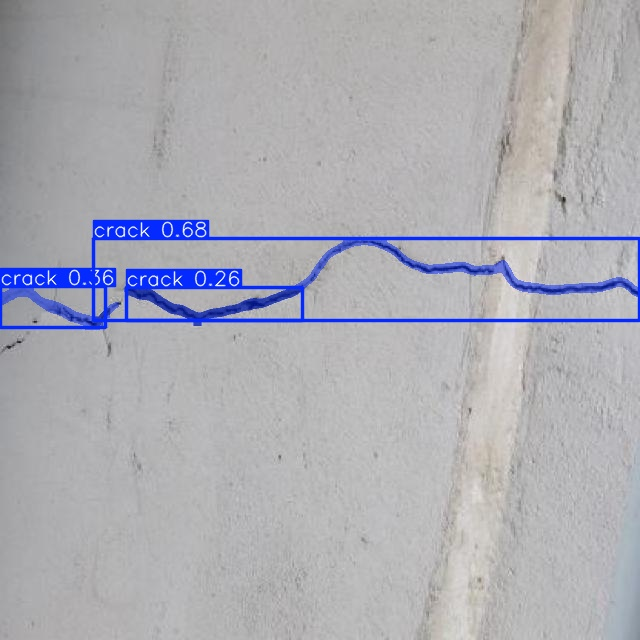

/content/predictions/crack_test/ds1_3068_jpg.rf.9bf4df1cd555674576f5da7da1b7d2ae.jpg


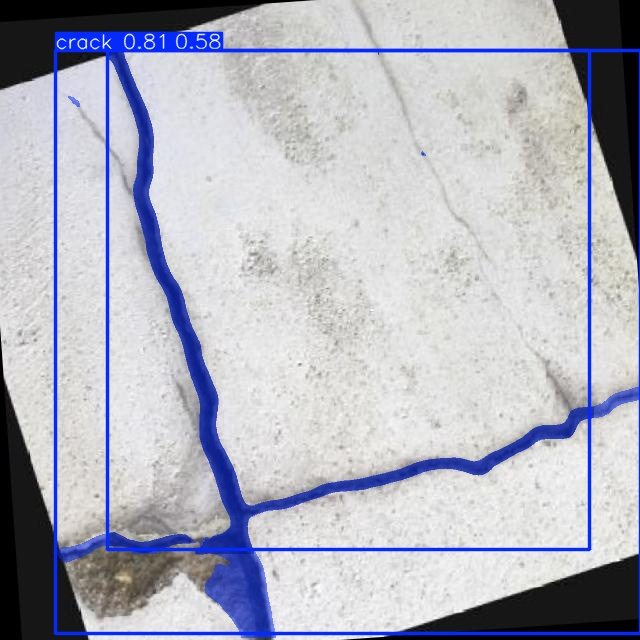

/content/predictions/crack_test/ds1_3285_jpg.rf.c3aea08bd3cb87509110ed3ba251f664.jpg


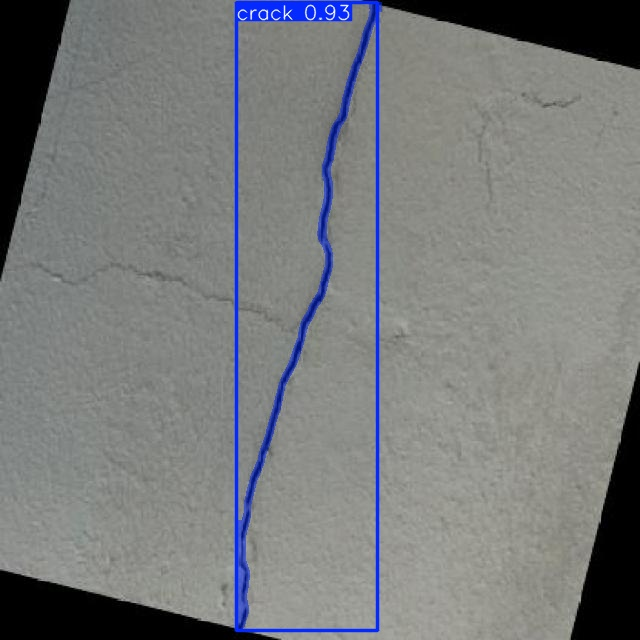

/content/predictions/crack_test/ds1_2052_jpg.rf.4ac610d92a31f9460703c2dd9040e364.jpg


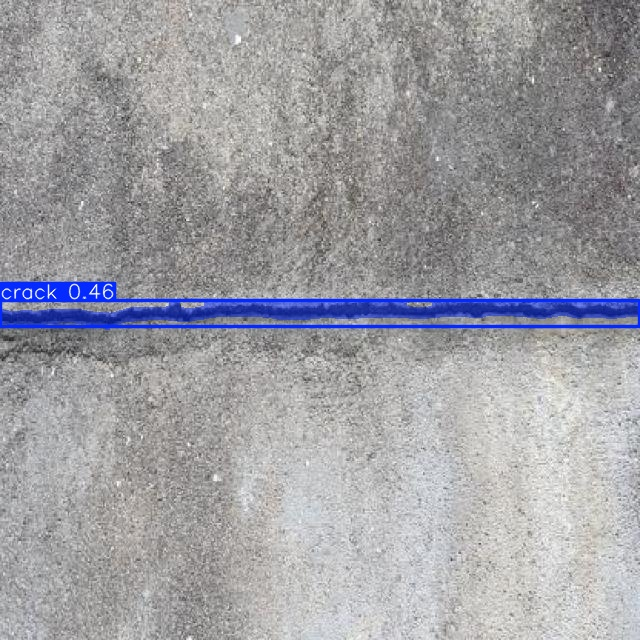

/content/predictions/crack_test/ds1_2339_jpg.rf.99e4c5bfa12d0d83088c8bced92f6632.jpg


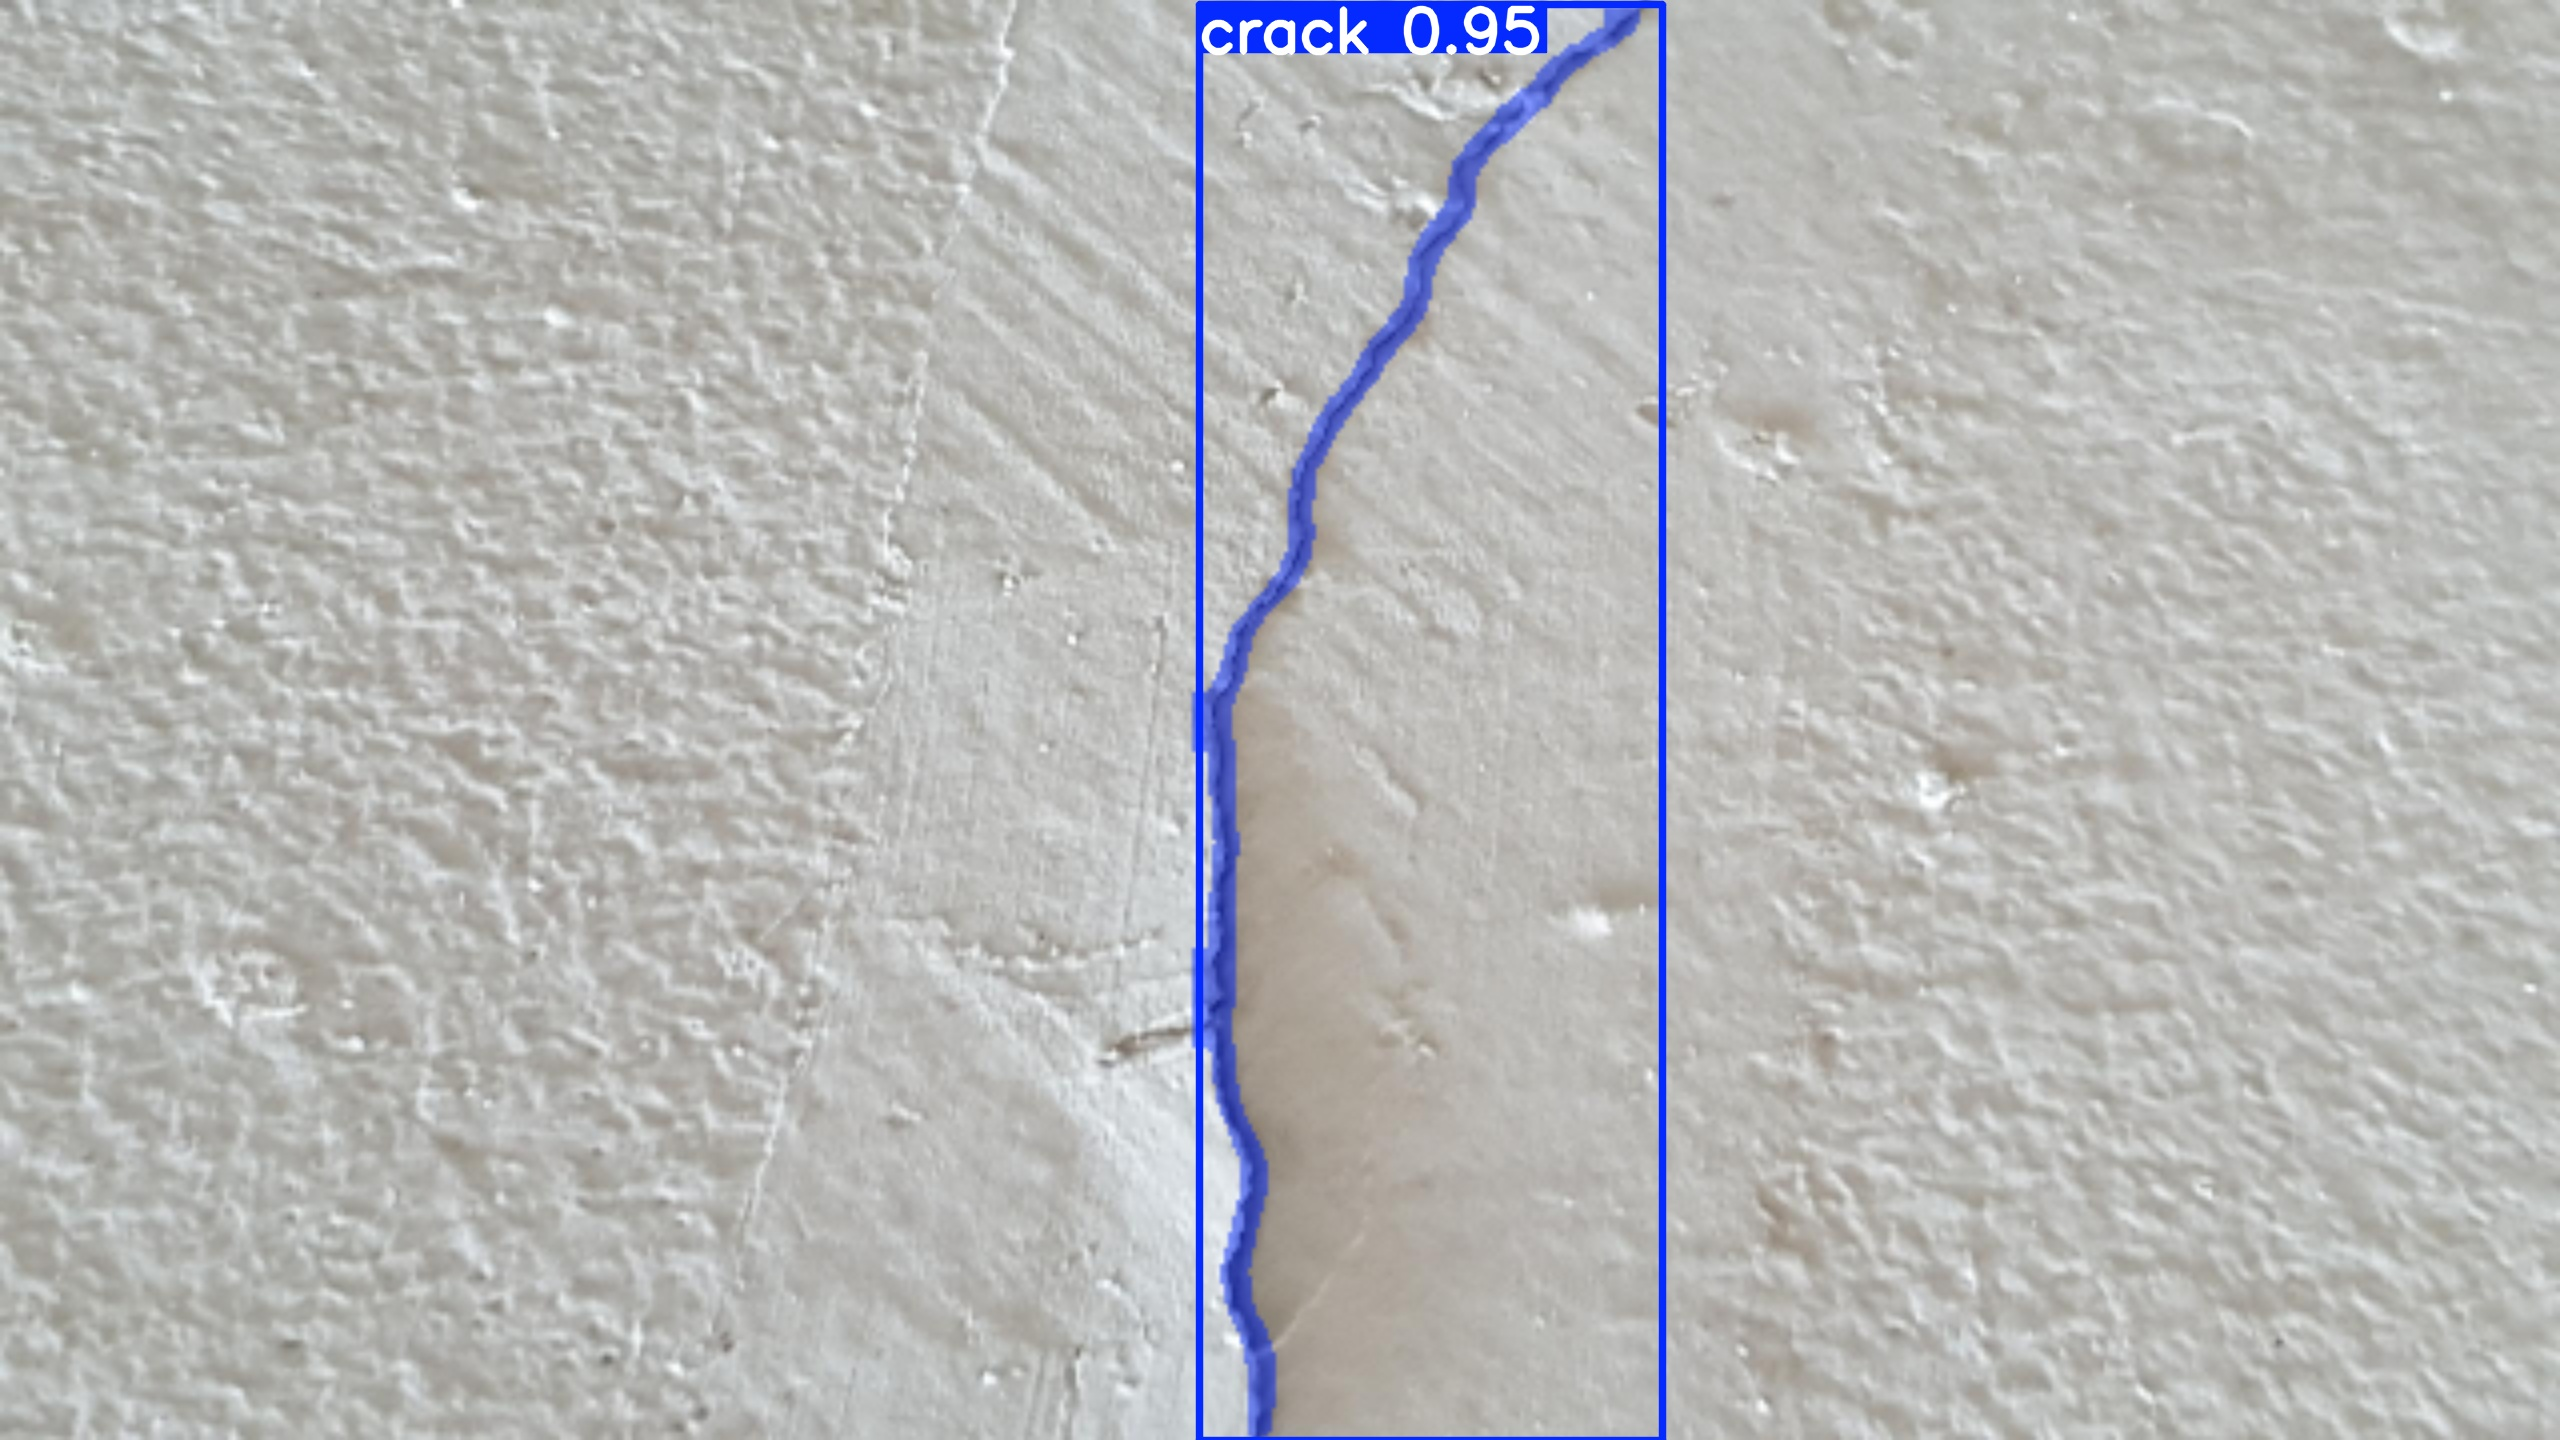

/content/predictions/crack_test/ds2_2322.rf.f07aacd92036f5be44b09ca976e11f17.jpg


In [60]:
pred_images = glob.glob('/content/predictions/crack_test/*.jpg')
for img_path in pred_images[:5]:
    display(Image(filename=img_path, width=640))
    print(img_path)

In [61]:
from IPython.display import Image, display
import os


In [62]:
run_dir = os.path.join(PROJECT_DIR, EXPERIMENT_NAME)


In [63]:
plots = [
    ('Curvas de entrenamiento', 'results.png'),
    ('Matriz de confusion',     'confusion_matrix.png'),
    ('Curva PR',                'PR_curve.png'),
    ('Curva F1',                'F1_curve.png'),
]



Curvas de entrenamiento:


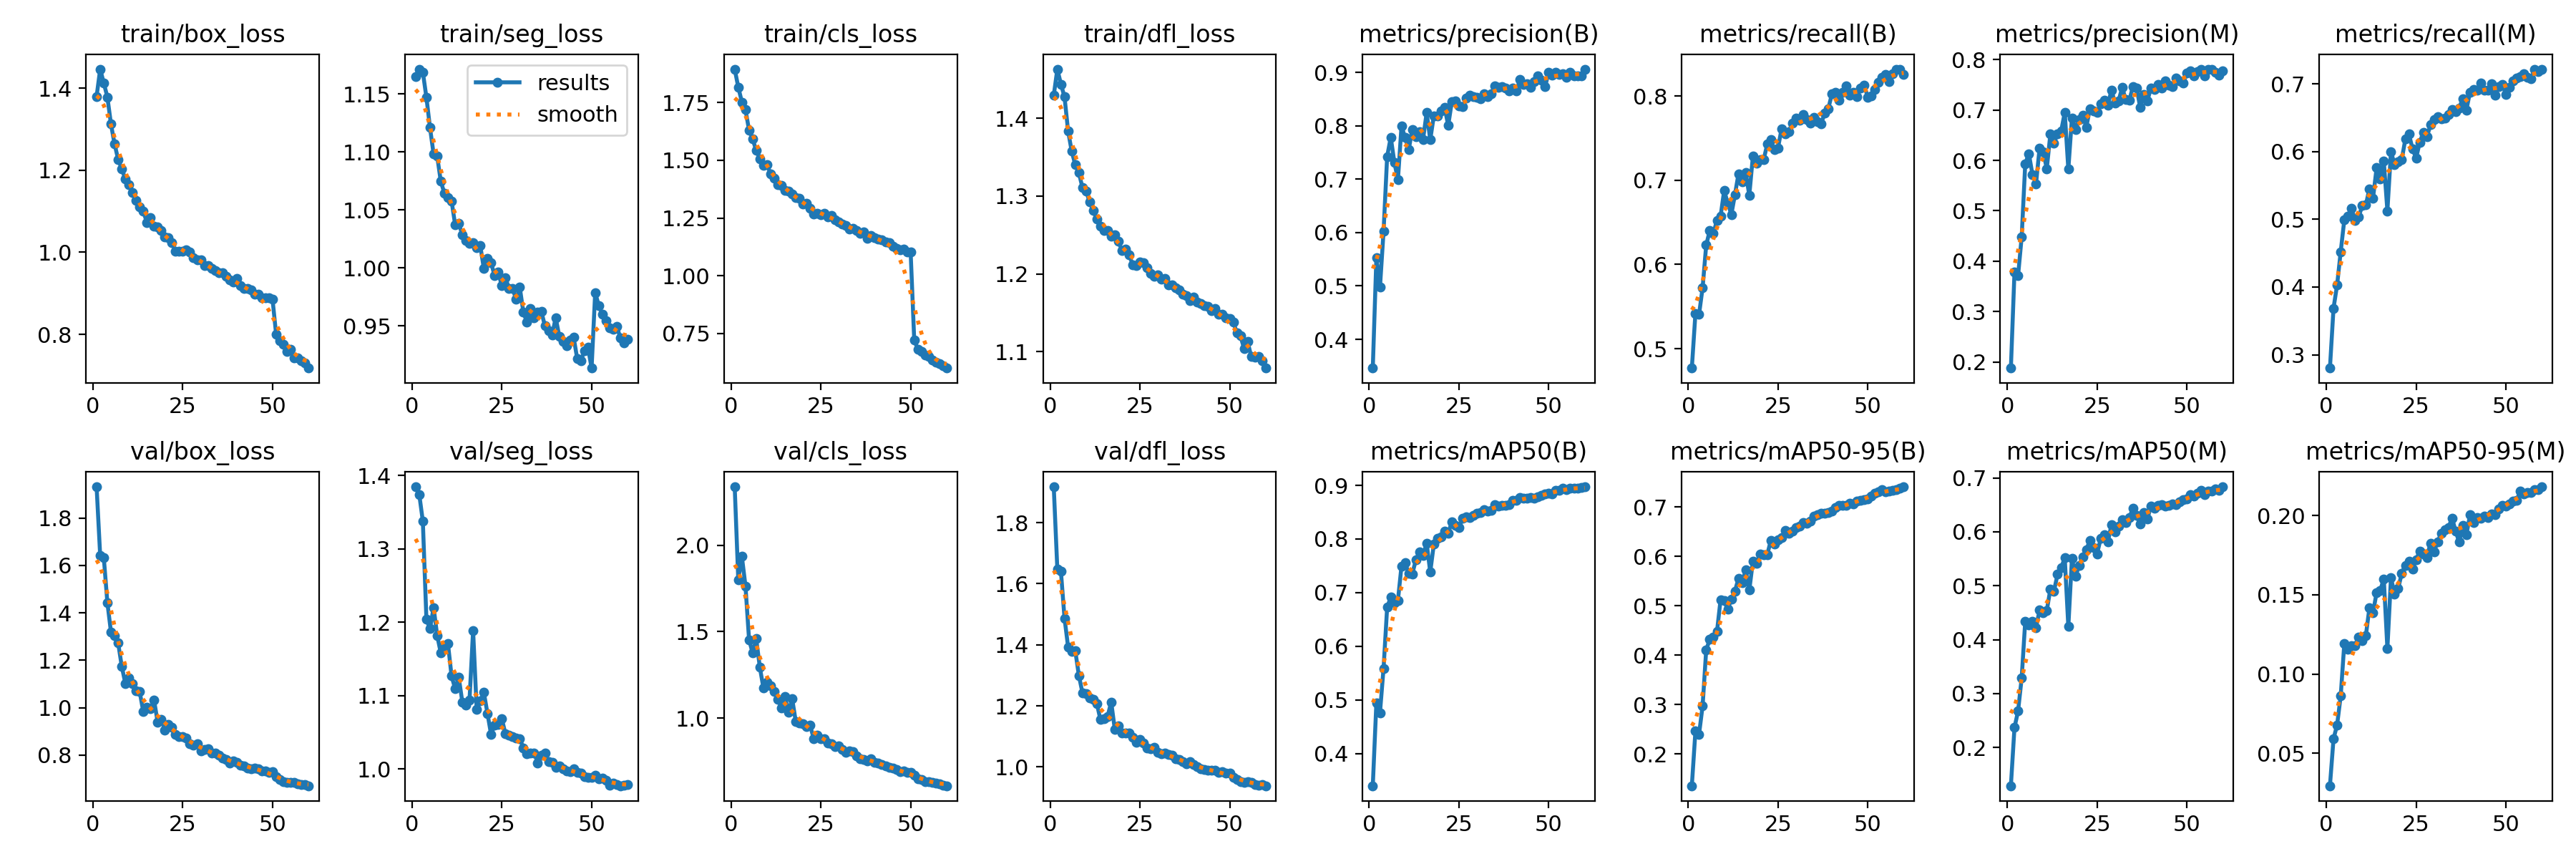


Matriz de confusion:


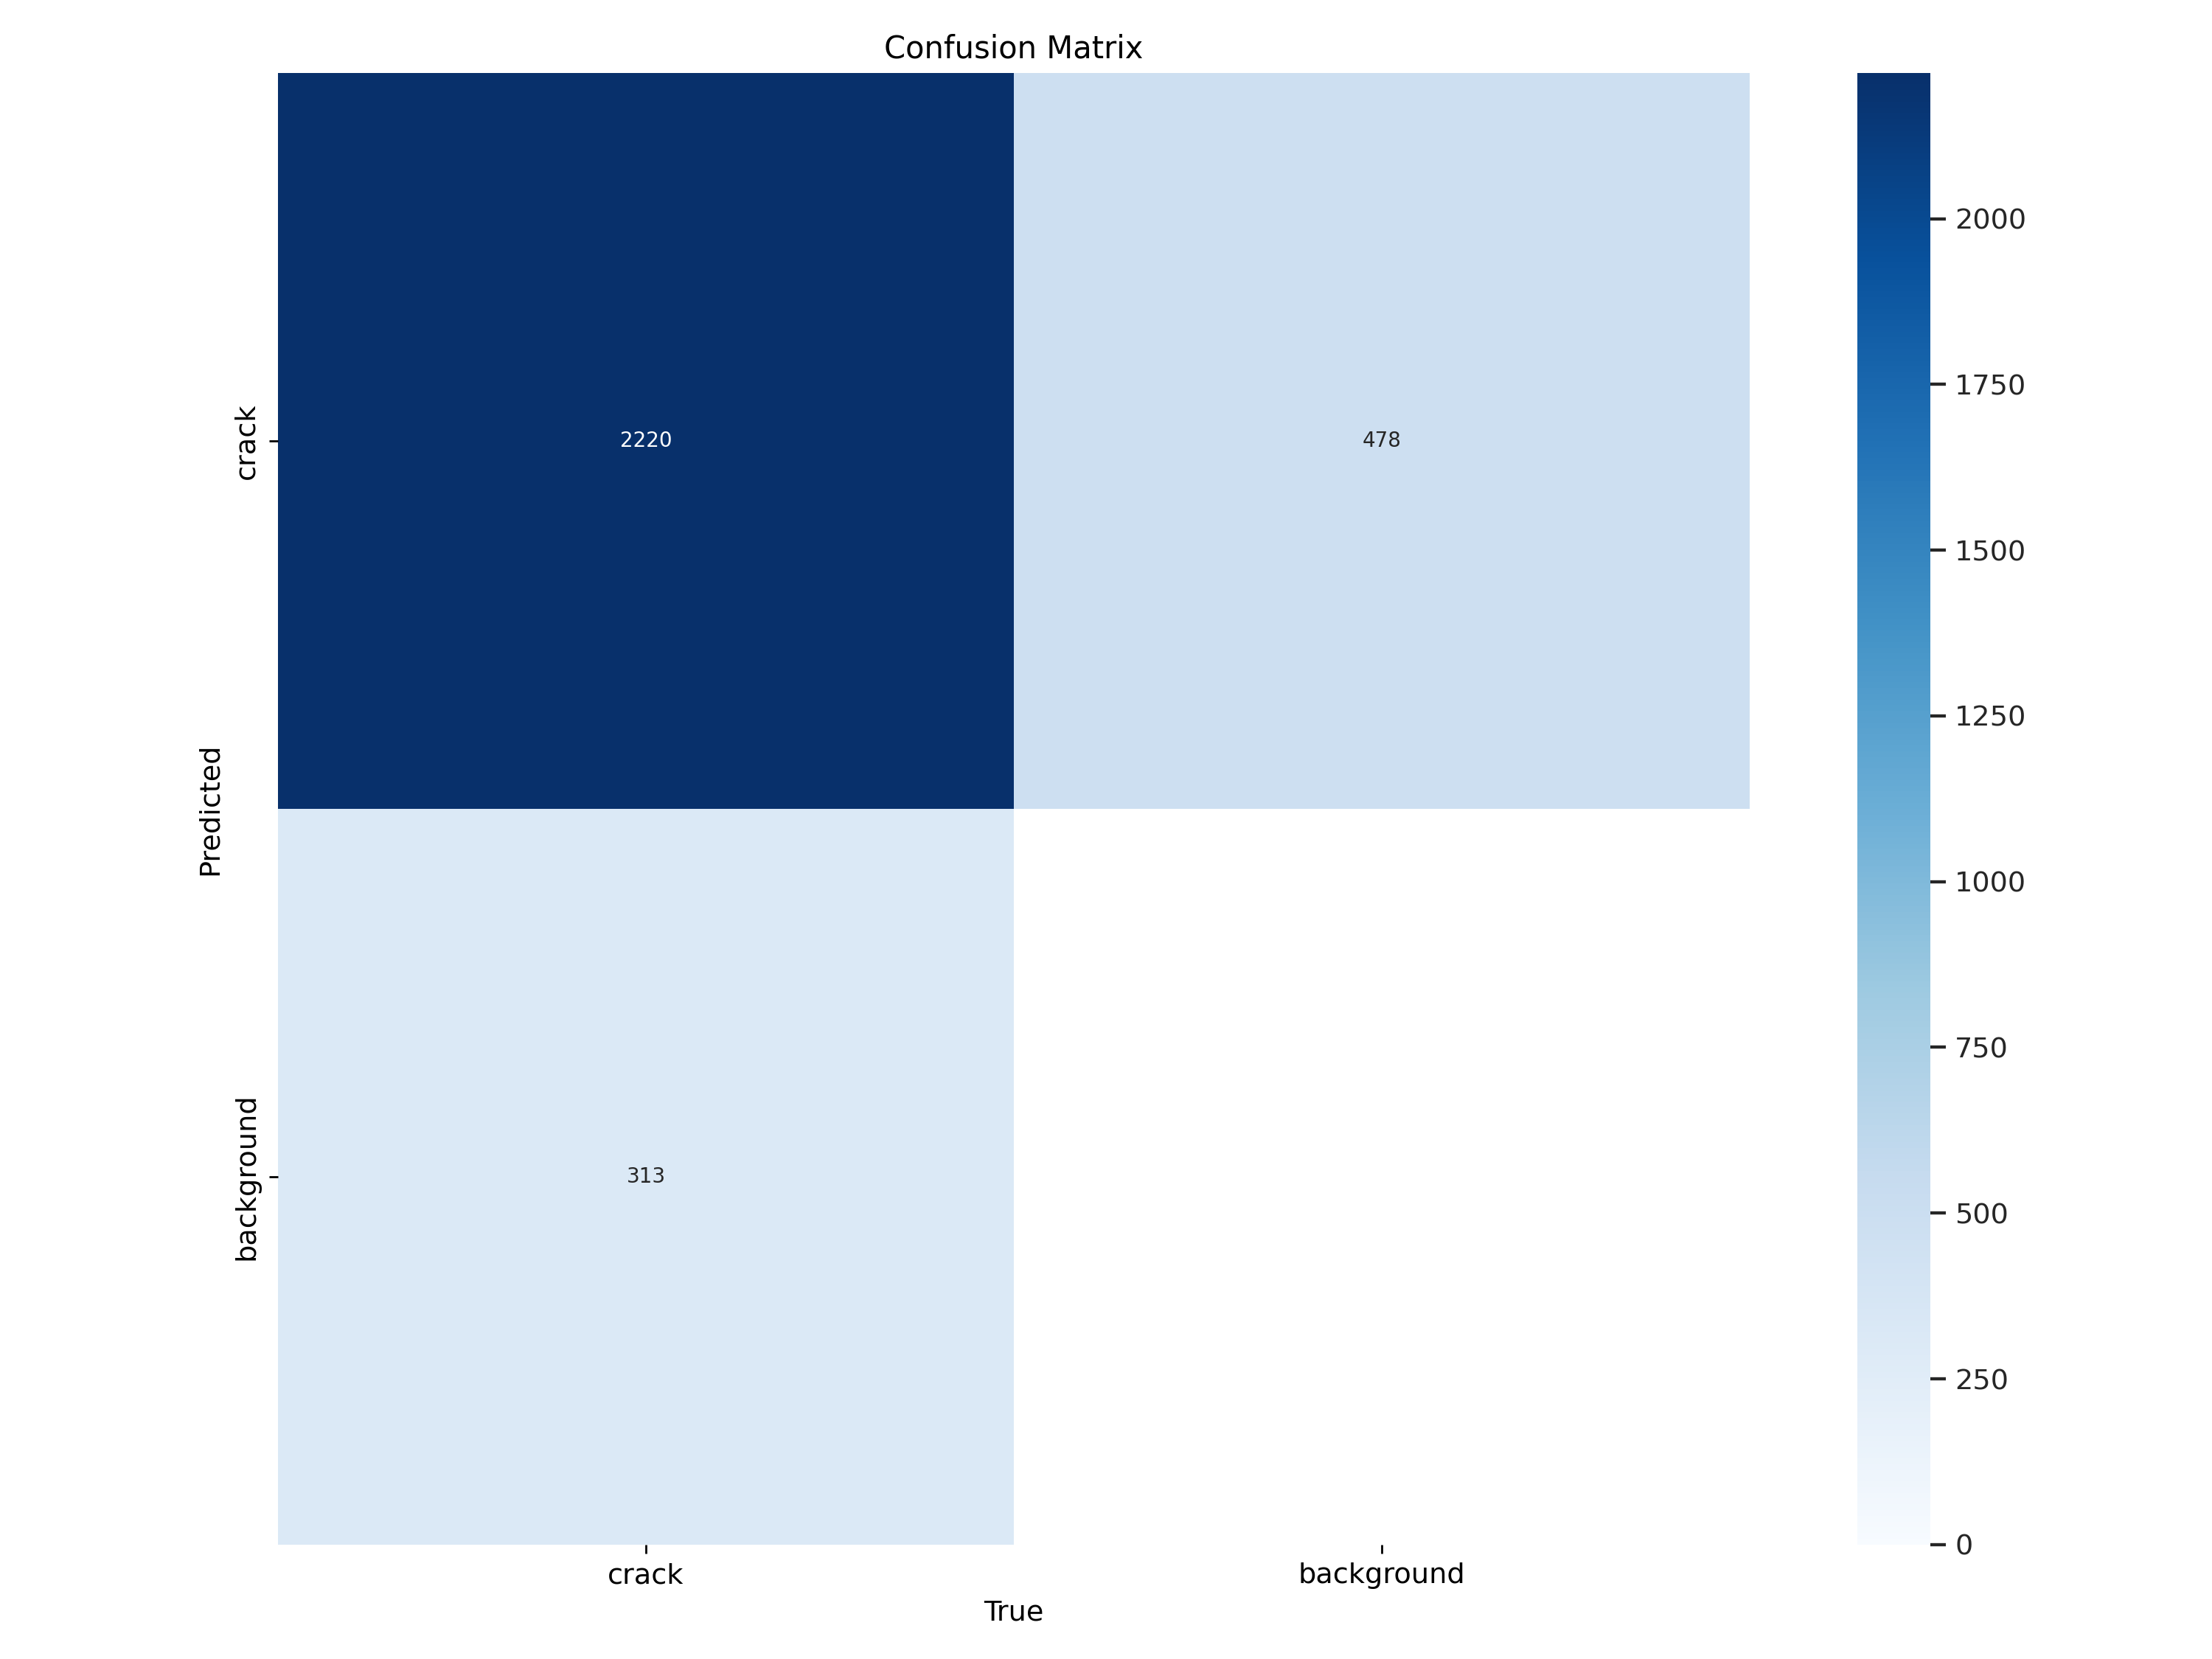

[No encontrado] /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/PR_curve.png
[No encontrado] /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/F1_curve.png


In [64]:
for title, filename in plots:
    img_path = os.path.join(run_dir, filename)
    if os.path.exists(img_path):
        print(f'\n{title}:')
        display(Image(filename=img_path, width=800))
    else:
        print(f'[No encontrado] {img_path}')

In [82]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/689.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 686.1/689.1 kB 20.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/164.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 18.2 MB/s eta 0:00:00


In [89]:
from ultralytics import YOLO
import os

best_weights = os.path.join(PROJECT_DIR, EXPERIMENT_NAME, 'weights', 'best.pt')
model_export = YOLO(best_weights)

model_export.export(
    format='onnx',
    imgsz=640,
    opset=12,
    simplify=True,
    dynamic=False,
)

onnx_path = best_weights.replace('.pt', '.onnx')

if os.path.exists(onnx_path):
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f'Modelo exportado correctamente.')
    print(f'Ruta:  {onnx_path}')
    print(f'Tamano: {size_mb:.1f} MB')
else:
    print('Error: el archivo .onnx no fue generado.')

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon 2.00GHz)
YOLOv8n-seg summary (fused): 195 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 37, 8400), (1, 32, 160, 160)) (6.5 MB)

ONNX: starting export with onnx 1.20.1 opset 12...


W0324 03:24:25.818000 6304 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0324 03:24:26.327000 6304 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0324 03:24:26.328000 6304 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -

Applied 1 of general pattern rewrite rules.
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 5.0s, saved as '/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.onnx' (12.6 MB)

Export complete (5.5s)
Results saved to /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights
Predict:         yolo predict task=segment model=/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.onnx imgsz=640  
Validate:        yolo val task=segment model=/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.onnx imgsz=640 data=/content/crack_combined/data.yaml  
Visualize:       https://netron.app
Modelo exportado correctamente.
Ruta:  /content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.onnx
Tamano: 12.6 MB


In [84]:
import onnx

onnx_path = '/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.onnx'
model_onnx = onnx.load(onnx_path)

opset = model_onnx.opset_import[0].version
print(f'Opset del modelo exportado: {opset}')
print(f'Tamano del modelo: {os.path.getsize(onnx_path) / (1024*1024):.1f} MB')
print(f'IR version: {model_onnx.ir_version}')

Opset del modelo exportado: 18
Tamano del modelo: 12.6 MB
IR version: 10


In [85]:
import os

run_dir = os.path.join(PROJECT_DIR, EXPERIMENT_NAME)
weights_dir = os.path.join(run_dir, 'weights')

print('Archivos guardados en Google Drive:')
print(f'  Directorio del experimento: {run_dir}')
print()

if os.path.exists(weights_dir):
    print('  Pesos disponibles:')
    for f in os.listdir(weights_dir):
        full_path = os.path.join(weights_dir, f)
        size_mb = os.path.getsize(full_path) / (1024 * 1024)
        print(f'    {f} ({size_mb:.1f} MB)')


print(f'  from ultralytics import YOLO')
print(f'  model = YOLO("{os.path.join(weights_dir, "best.pt")}")')

Archivos guardados en Google Drive:
  Directorio del experimento: /content/drive/MyDrive/crack_detector/runs/crack_seg_v1

  Pesos disponibles:
    last.pt (6.5 MB)
    best.pt (6.5 MB)
    best.onnx.data (12.6 MB)
    best.onnx (12.6 MB)
  from ultralytics import YOLO
  model = YOLO("/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt")



image 1/1 /content/test_images/cracked_wall_03.jpg: 480x640 1 crack, 9.8ms
Speed: 3.0ms preprocess, 9.8ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs/segment/predict15


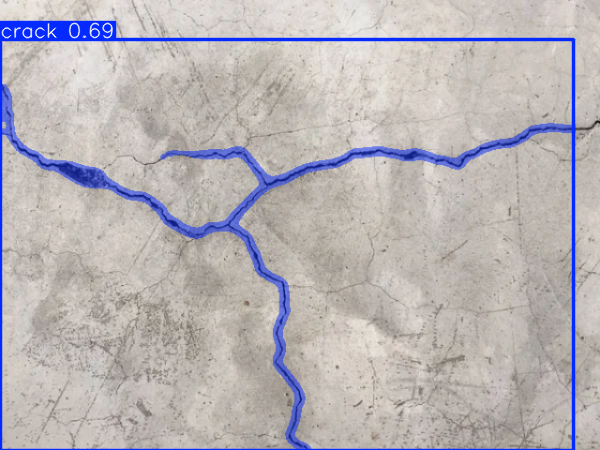

In [86]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow


model_path = '/content/drive/MyDrive/crack_detector/runs/crack_seg_v1/weights/best.pt'
model = YOLO(model_path)

results = model.predict(source='/content/test_images/cracked_wall_03.jpg', conf=0.15, save=True)


for r in results:
    im_array = r.plot()
    cv2_imshow(im_array)